## Описание ноутбука

В ноутбуке решается задача прогноза `target_2h` по маршрутам с постановкой direct multi-step forecasting.
Вместо табличного CatBoost используется **LSTM (Long Short-Term Memory)** — рекуррентная sequence-модель на чистом PyTorch.
Модель получает на вход окно из последних `SEQ_LEN` исторических шагов по маршруту и предсказывает сразу `FORECAST_POINTS=10` будущих значений `target_2h`.
Валидация строится по времени (time-based split), чтобы имитировать реальный сценарий применения.
Финальная цель: получить прогнозы на тесте и собрать submission в требуемом формате.

In [2]:
import copy
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

TRACK = "team"  # "solo" or "team"
RANDOM_STATE = 42
FORECAST_POINTS = 10
MAX_TRAIN_SAMPLES = 2_000_000
SEQ_LEN = 48       # 48 шагов = 24 часа (шаг 30 мин)
VALID_DAYS = 2

# Training hyperparameters
BATCH_SIZE = 64  # Уменьшен для лучшей генерализации
EPOCHS = 25  # Увеличено для более глубокого обучения
LR = 5e-4  # Увеличена learning rate
WEIGHT_DECAY = 5e-4  # Уменьшена регуляризация
PATIENCE = 5
NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# LSTM architecture (улучшенная конфигурация)
LSTM_HIDDEN_SIZE = 256  # Увеличено с 128 на 256
LSTM_NUM_LAYERS = 3  # Увеличено с 2 на 3
DROPOUT = 0.2  # Увеличено для регуляризации
ROUTE_EMB_DIM = 32  # Увеличено с 16 на 32
OFFICE_EMB_DIM = 8
BIDIRECTIONAL = True  # Добавлен Bidirectional LSTM

TRACK_CONFIG = {
    "solo": {
        "train_path": "../raw/train_solo_track.parquet",
        "test_path": "../raw/test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "../raw/train_team_track.parquet",
        "test_path": "../raw/test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]

print("Device:", DEVICE)
print("SEQ_LEN:", SEQ_LEN, "FORECAST_POINTS:", FORECAST_POINTS)
print(f"LSTM config: hidden_size={LSTM_HIDDEN_SIZE}, num_layers={LSTM_NUM_LAYERS}, bidirectional={BIDIRECTIONAL}")

Device: cpu
SEQ_LEN: 48 FORECAST_POINTS: 10
LSTM config: hidden_size=256, num_layers=3, bidirectional=True


## 1. Загрузка данных

In [4]:
train_df = pd.read_parquet(CONFIG["train_path"])
test_df = pd.read_parquet(CONFIG["test_path"])

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # Циклическое кодирование времени суток
    minutes_of_day = df["hour"] * 60 + df["minute"]
    df["tod_sin"] = np.sin(2 * np.pi * minutes_of_day / 1440)
    df["tod_cos"] = np.cos(2 * np.pi * minutes_of_day / 1440)

    # Циклическое кодирование дня недели
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    return df


train_df = add_calendar_features(train_df)
test_df = add_calendar_features(test_df)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


track: team
train shape: (4342000, 20)
test shape: (10000, 11)


In [5]:
display(train_df.head())
display(test_df.head())


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,hour,minute,dayofweek,is_weekend,tod_sin,tod_cos,dow_sin,dow_cos
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0,0,0,5,1,0.000000,1.000000,-0.974928,-0.222521
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0,0,30,5,1,0.130526,0.991445,-0.974928,-0.222521
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0,1,0,5,1,0.258819,0.965926,-0.974928,-0.222521
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0,1,30,5,1,0.382683,0.923880,-0.974928,-0.222521
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0,2,0,5,1,0.500000,0.866025,-0.974928,-0.222521


,id,route_id,timestamp,hour,minute,dayofweek,is_weekend,tod_sin,tod_cos,dow_sin,dow_cos
0,4900,0,2025-05-30 11:00:00,11,0,4,0,2.588190e-01,-0.965926,-0.433884,-0.900969
1,4901,0,2025-05-30 11:30:00,11,30,4,0,1.305262e-01,-0.991445,-0.433884,-0.900969
2,4902,0,2025-05-30 12:00:00,12,0,4,0,1.224647e-16,-1.000000,-0.433884,-0.900969
3,4903,0,2025-05-30 12:30:00,12,30,4,0,-1.305262e-01,-0.991445,-0.433884,-0.900969
4,4904,0,2025-05-30 13:00:00,13,0,4,0,-2.588190e-01,-0.965926,-0.433884,-0.900969


In [6]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())


Train date range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test date range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00
Train routes: 1000
Test routes: 1000


На этом шаге проверяем базовую структуру train/test и временной диапазон данных.
Это позволяет подтвердить корректность входа в feature engineering и избежать ошибок на раннем этапе.

## 2. Первичный анализ train-данных

In [7]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
office_from_id,int64,0,0.0,53
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4342
status_1,int64,0,0.0,19752
status_2,int64,0,0.0,2127
status_3,int64,0,0.0,17998
status_4,int64,0,0.0,14416
status_5,int64,0,0.0,17108
status_6,int64,0,0.0,17616
status_7,int64,0,0.0,38219


In [8]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']
Target column: target_2h
Forecast points: 10


## 3. Распределения и визуальный sanity-check

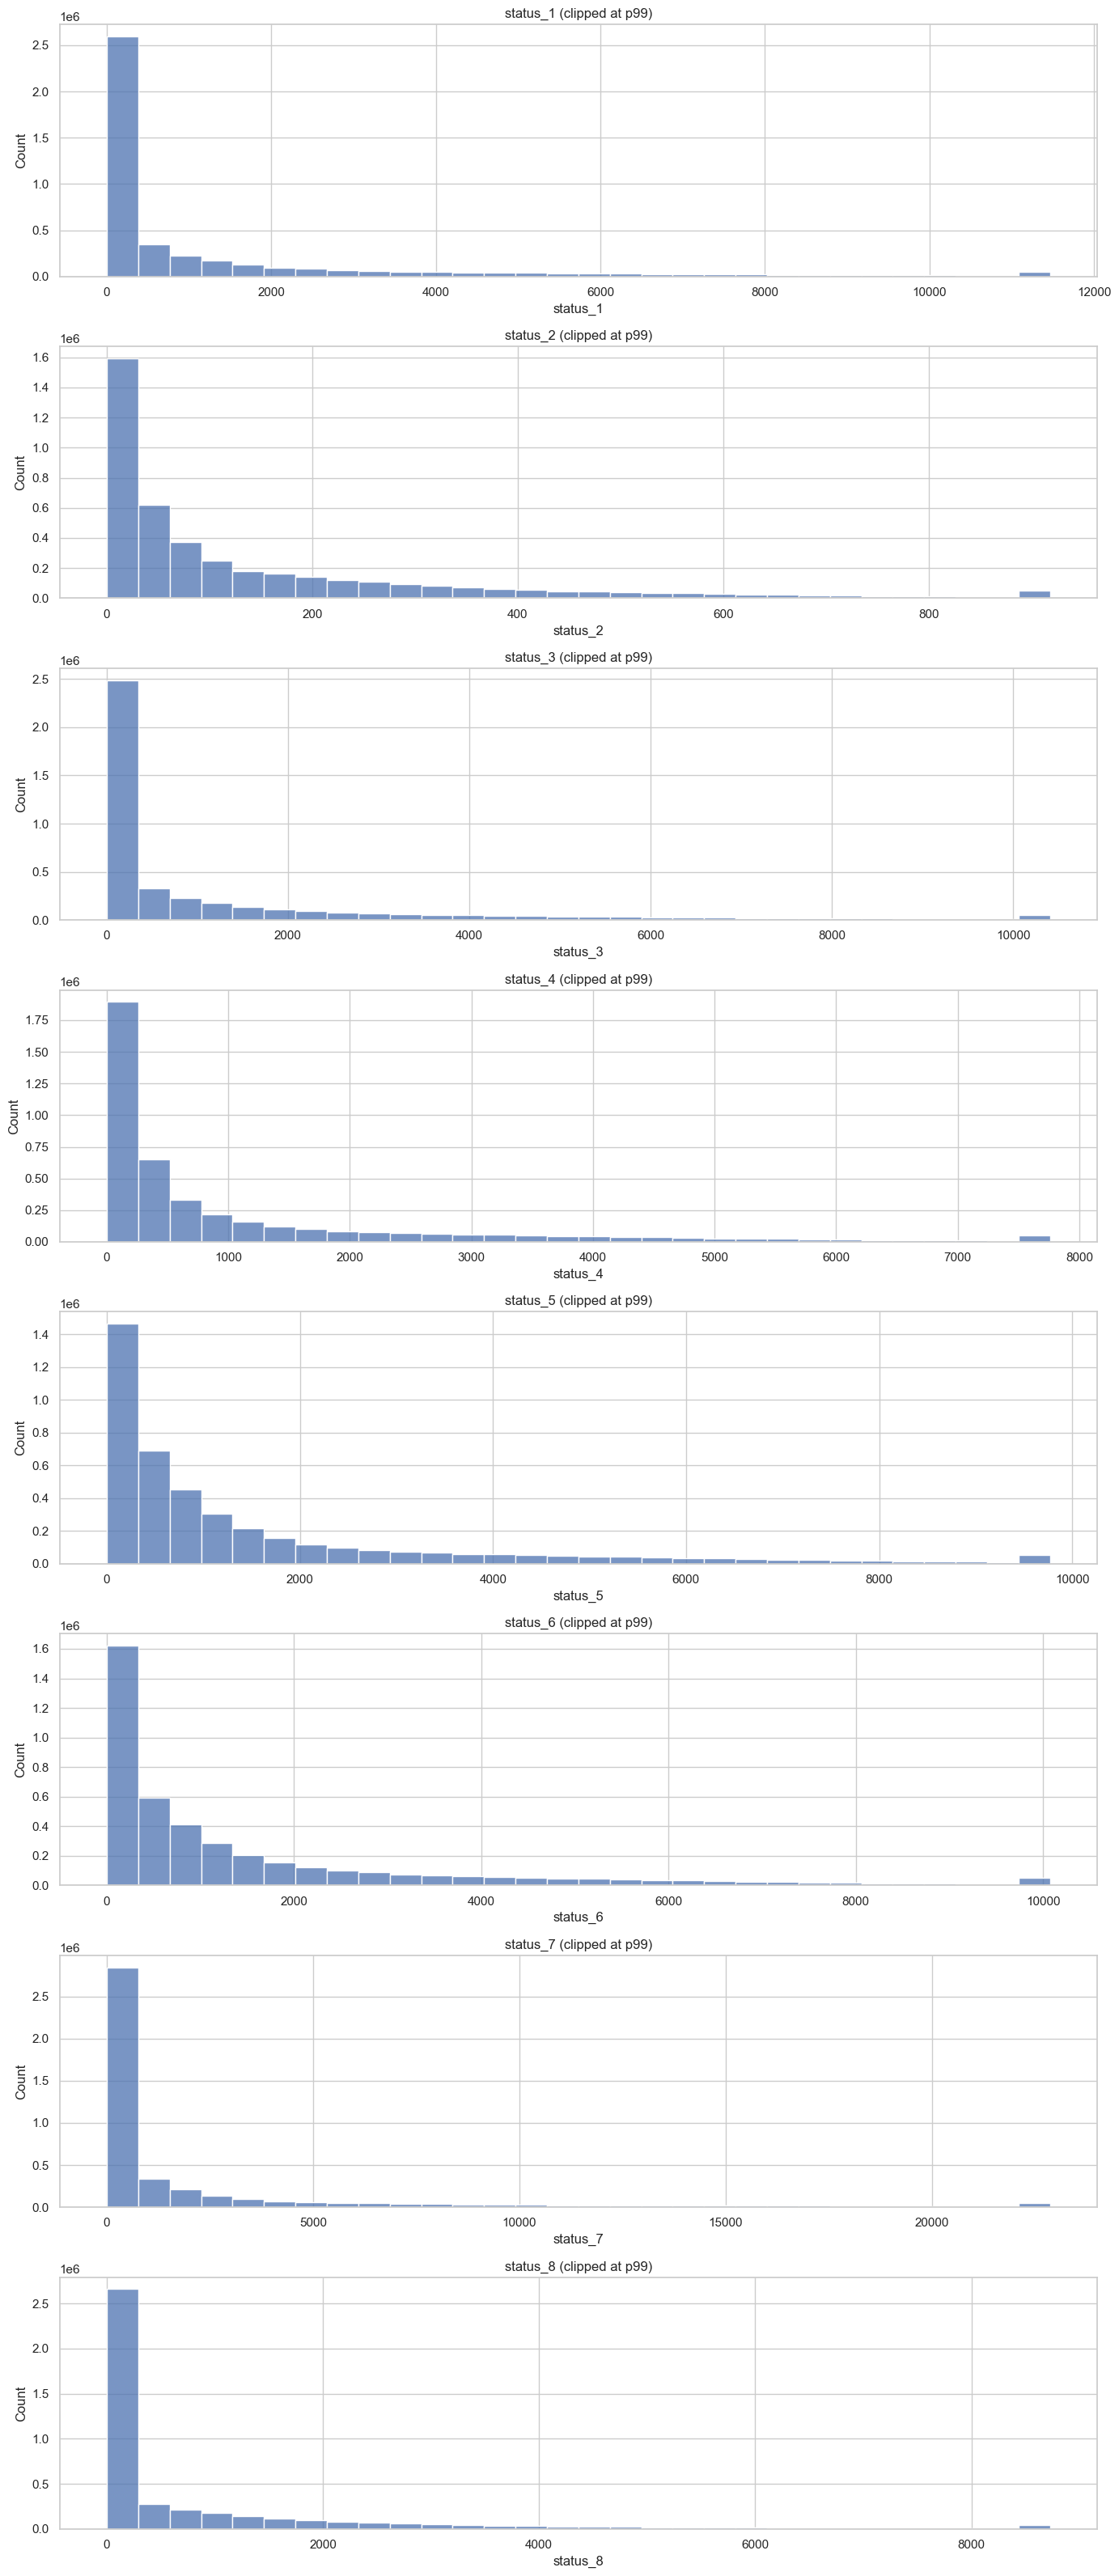

In [9]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


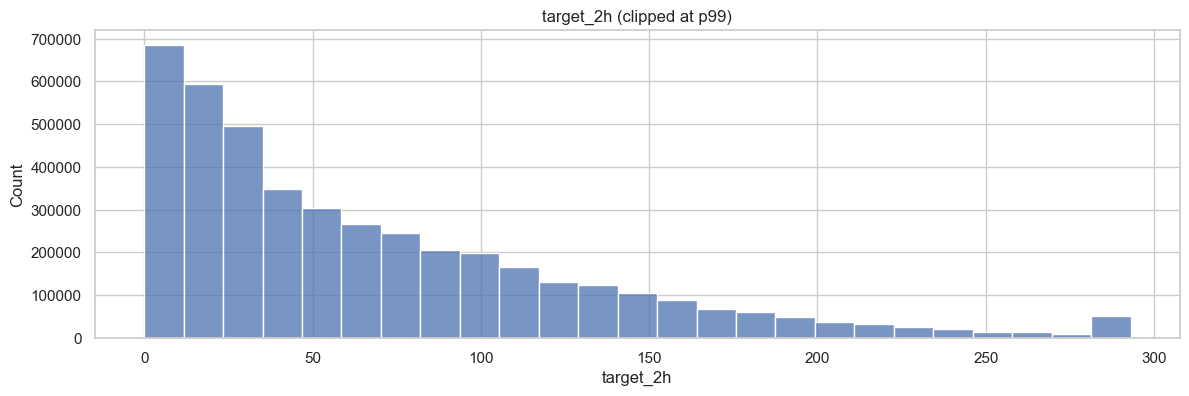

In [10]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


**Короткий итог после EDA**

- Данные имеют регулярную временную структуру по маршрутам.
- Базовые распределения и динамика целевого признака визуально согласованы.
- Постановка задачи как временного multi-step forecasting уместна.

## 4. Подготовка последовательностей для LSTM

В отличие от CatBoost, LSTM получает на вход **целое окно** из последних `SEQ_LEN` шагов истории,
поэтому нет необходимости вручную разматывать лаги или создавать rolling-фичи.
Достаточно добавить несколько простых агрегатов по статусам и передать всё как temporal sequence.

Категориальные признаки `route_id` и `office_from_id` кодируются через integer-индексы —
они попадут в embedding-слои модели, а не конвертируются в строки или one-hot.

In [11]:
status_cols = sorted([c for c in train_df.columns if c.startswith("status_")])

train_df["status_sum"] = train_df[status_cols].sum(axis=1)
train_df["status_mean"] = train_df[status_cols].mean(axis=1)
train_df["status_max"] = train_df[status_cols].max(axis=1)

missing_status = [c for c in status_cols if c not in test_df.columns]
if missing_status:
    for c in missing_status:
        test_df[c] = 0.0

test_df["status_sum"] = test_df[status_cols].sum(axis=1)
test_df["status_mean"] = test_df[status_cols].mean(axis=1)
test_df["status_max"] = test_df[status_cols].max(axis=1)

dynamic_cols = (
    [TARGET_COL]
    + status_cols
    + ["status_sum", "status_mean", "status_max"]
    + ["tod_sin", "tod_cos", "dow_sin", "dow_cos", "is_weekend"]
)

print(f"Dynamic features ({len(dynamic_cols)}): {dynamic_cols}")

Dynamic features (17): ['target_2h', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'status_sum', 'status_mean', 'status_max', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'is_weekend']


### Целочисленное кодирование маршрутов и офисов

Embeddings позволяют модели самостоятельно выучить скрытые представления для каждого маршрута и офиса.
Для этого достаточно присвоить каждому уникальному значению целочисленный индекс.

In [12]:
all_routes = sorted(train_df["route_id"].unique())
all_offices = sorted(train_df["office_from_id"].unique())

route2idx = {r: i for i, r in enumerate(all_routes)}
office2idx = {o: i for i, o in enumerate(all_offices)}

train_df["route_idx"] = train_df["route_id"].map(route2idx)


# test_df может содержать route_id / office_from_id из train
test_df["route_idx"] = test_df["route_id"].map(route2idx).fillna(0).astype(int)

NUM_ROUTES = len(route2idx)
NUM_OFFICES = len(office2idx)
print(f"Уникальных маршрутов: {NUM_ROUTES}, офисов: {NUM_OFFICES}")

Уникальных маршрутов: 1000, офисов: 53


## 5. Построение sequence samples

Для каждого маршрута применяется скользящее окно (sliding window):
- история длиной `SEQ_LEN` шагов — это признаки;
- следующие `FORECAST_POINTS` шагов — это таргет.

Функция `build_sequence_samples` возвращает:
- `route_arrays` — numpy-массивы фич и таргетов по каждому маршруту (компактное хранение);
- `all_samples` — список метаданных по каждому sample (route_key, local_end_pos, source_timestamp).

Это позволяет Dataset в runtime доставать нужные окна без копирования данных.

In [13]:
def build_sequence_samples(df, seq_len, horizon, dynamic_cols):
    """
    Sliding-window samples для каждого route_id.
    Возвращает:
      route_arrays: dict {route_key: {"features", "targets", "timestamps",
                                       "route_idx", "office_idx"}}
      samples: list of {route_key, local_end_pos, source_timestamp}
    """
    route_arrays = {}
    samples = []

    for route_key, grp in df.groupby("route_id", sort=False):
        grp = grp.reset_index(drop=True)
        n = len(grp)

        feats = grp[dynamic_cols].to_numpy(dtype=np.float32)
        tgts = grp[TARGET_COL].to_numpy(dtype=np.float32)
        ts = grp["timestamp"].values
        r_idx = int(grp["route_idx"].iloc[0])

        route_arrays[route_key] = {
            "features": feats,
            "features_scaled": None,
            "targets": tgts,
            "timestamps": ts,
            "route_idx": r_idx
        }

        for end_pos in range(seq_len - 1, n - horizon):
            samples.append({
                "route_key": route_key,
                "local_end_pos": end_pos,
                "source_timestamp": ts[end_pos],
            })

    return route_arrays, samples


route_arrays, all_samples = build_sequence_samples(
    train_df, SEQ_LEN, FORECAST_POINTS, dynamic_cols
)
print(f"Маршрутов: {len(route_arrays)}, всего сэмплов: {len(all_samples)}")

Маршрутов: 1000, всего сэмплов: 4285000


## 6. Временное разбиение на fit и valid

Split идёт строго по времени (`source_timestamp`):
- `fit`: всё до последних `VALID_DAYS` дней;
- `valid`: последние `VALID_DAYS` дней.

`StandardScaler` фитируется **только на fit-части** и затем применяется ко всем данным.

In [14]:
max_source_ts = pd.Timestamp(max(s["source_timestamp"] for s in all_samples))
gap = pd.Timedelta(minutes=30 * FORECAST_POINTS)

valid_start = max_source_ts - pd.Timedelta(days=VALID_DAYS)
valid_start_np = np.datetime64(valid_start)

fit_samples = [s for s in all_samples if s["source_timestamp"] < np.datetime64(valid_start - gap)][-MAX_TRAIN_SAMPLES:]
valid_samples = [s for s in all_samples if s["source_timestamp"] >= valid_start_np]

print(f"valid_start: {valid_start}")
print(f"Fit samples: {len(fit_samples)}, Valid samples: {len(valid_samples)}")

valid_start: 2025-05-28 05:30:00
Fit samples: 2000000, Valid samples: 97000


In [15]:
fit_min_ts = pd.Timestamp(min(s["source_timestamp"] for s in fit_samples))
fit_max_ts = pd.Timestamp(max(s["source_timestamp"] for s in fit_samples))

fit_mask = (train_df["timestamp"] >= fit_min_ts) & (train_df["timestamp"] <= fit_max_ts)

scaler = StandardScaler()
scaler.fit(train_df.loc[fit_mask, dynamic_cols].values)

for arr in route_arrays.values():
    arr["features_scaled"] = scaler.transform(arr["features"])

## 7. Dataset и DataLoader

`RouteSequenceDataset` возвращает один sample:
- `x_seq` — масштабированное окно истории `[SEQ_LEN, num_features]`;
- `route_idx`, `office_idx` — целочисленные индексы для embedding-слоёв;
- `y` — следующие `FORECAST_POINTS` значений таргета.

In [16]:
class RouteSequenceDataset(Dataset):
    def __init__(self, samples, route_arrays, seq_len, horizon):
        self.samples = samples
        self.route_arrays = route_arrays
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        arr = self.route_arrays[s["route_key"]]
        end = s["local_end_pos"]

        x_seq = arr["features_scaled"][end - self.seq_len + 1: end + 1]  # [L, F]
        y = arr["targets"][end + 1: end + 1 + self.horizon]               # [H]

        return {
            "x_seq": torch.from_numpy(x_seq.copy()),
            "route_idx": torch.tensor(arr["route_idx"], dtype=torch.long),
            "y": torch.from_numpy(y.copy()),
        }

In [17]:
train_dataset = RouteSequenceDataset(fit_samples, route_arrays, SEQ_LEN, FORECAST_POINTS)
valid_dataset = RouteSequenceDataset(valid_samples, route_arrays, SEQ_LEN, FORECAST_POINTS)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}")

Train batches: 31250, Valid batches: 1516


## 8. LSTM-модель с Attention механизмом

Архитектура: **LSTMForecaster с Bidirectional LSTM и MultiheadAttention**

```
x_seq [B, L, F]
    → Bidirectional LSTM (3 слоя, hidden=256) [B, L, 512]
    → MultiheadAttention (8 heads) [B, L, 512]
    → last timestep [B, 512]
    → concat с route_emb [B, 32]
    → MLP head (512 → 256 → 128 → FORECAST_POINTS)
    → [B, FORECAST_POINTS]
```

**Улучшения:**
- Bidirectional LSTM позволяет модели смотреть на контекст в оба направления
- MultiheadAttention механизм выделяет важные временные шаги
- Расширенная MLP head с большей емкостью
- Gradient clipping для стабильного обучения
- CosineAnnealingWarmRestarts scheduler для лучшей сходимости


In [18]:
class LSTMForecaster(nn.Module):
    def __init__(
        self,
        num_features,
        num_routes,
        forecast_points,
        hidden_size=256,
        num_layers=3,
        dropout=0.2,
        route_emb_dim=32,
        bidirectional=True,
    ):
        super().__init__()
        self.route_emb = nn.Embedding(num_routes, route_emb_dim)
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )

        # Attention слой
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size * (2 if bidirectional else 1),
            num_heads=8,
            dropout=dropout,
            batch_first=True,
        )

        lstm_out_size = hidden_size * (2 if bidirectional else 1)
        head_in = lstm_out_size + route_emb_dim

        # Расширенный head с большей емкостью
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, forecast_points),
        )

    def forward(self, x_seq, route_idx):
        # x_seq: [B, L, F]
        lstm_out, (h_n, c_n) = self.lstm(x_seq)
        # lstm_out: [B, L, hidden_size * 2] если bidirectional
        
        # Применяем attention к выходу LSTM
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        # Берём последний timestep после attention
        h_last = attn_out[:, -1, :]  # [B, hidden_size * 2]

        r_emb = self.route_emb(route_idx)

        x = torch.cat([h_last, r_emb], dim=1)
        return self.head(x)


In [19]:
torch.manual_seed(RANDOM_STATE)

model = LSTMForecaster(
    num_features=len(dynamic_cols),
    num_routes=NUM_ROUTES,
    forecast_points=FORECAST_POINTS,
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    dropout=DROPOUT,
    route_emb_dim=ROUTE_EMB_DIM,
    bidirectional=BIDIRECTIONAL,
).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LSTM parameters: {num_params:,}")
print(f"Device: {DEVICE}")
print(f"Model with Attention mechanism and Bidirectional LSTM enabled")

LSTM parameters: 5,244,298
Device: cpu
Model with Attention mechanism and Bidirectional LSTM enabled


## 9. Обучение LSTM с оптимизированной стратегией

- Оптимизатор: `AdamW` с пониженным weight decay
- Функция потерь: `SmoothL1Loss` с beta=0.1 (более чувствительна)
- Scheduler: `CosineAnnealingWarmRestarts` для адаптивного снижения LR
- Gradient clipping для стабильности
- Early stopping по valid loss с patience = `PATIENCE`
- Сохраняется best state_dict по минимальному valid loss


In [20]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,
    T_mult=1,
    eta_min=1e-6
)

criterion = nn.SmoothL1Loss(beta=0.1)  # Сделана более чувствительной

best_valid_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        x_seq = batch["x_seq"].to(DEVICE)
        route_idx = batch["route_idx"].to(DEVICE)
        y = batch["y"].to(DEVICE)

        optimizer.zero_grad()
        pred = model(x_seq, route_idx)
        loss = criterion(pred, y)
        loss.backward()
        # Gradient clipping для стабильности
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(y)

    train_loss /= len(train_loader.dataset)

    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for batch in valid_loader:
            x_seq = batch["x_seq"].to(DEVICE)
            route_idx = batch["route_idx"].to(DEVICE)
            y = batch["y"].to(DEVICE)
            pred = model(x_seq, route_idx)
            loss = criterion(pred, y)
            valid_loss += loss.item() * len(y)

    valid_loss /= len(valid_loader.dataset)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d}/{EPOCHS} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | lr={current_lr:.2e}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nBest valid loss: {best_valid_loss:.4f}")

Epoch 001/25 | train_loss=20.7126 | valid_loss=20.3625 | lr=4.52e-04
Epoch 002/25 | train_loss=19.2222 | valid_loss=20.3819 | lr=3.28e-04


KeyboardInterrupt: 

## 10. Оценка качества

Метрика `WapePlusRbias = WAPE + |RBias|` вычисляется:
- **по горизонтам** на valid (step 1..10);
- **overall** — на всех горизонтах и сэмплах вместе.

In [ ]:
class WapePlusRbias:
    """Calculates WAPE + Relative Bias."""

    @property
    def name(self):
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        wape = np.abs(y_pred - y_true).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return float(wape + rbias)


metric = WapePlusRbias()


def predict_loader(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            x_seq = batch["x_seq"].to(device)
            route_idx = batch["route_idx"].to(device)
            pred = model(x_seq, route_idx).cpu().numpy()
            all_preds.append(pred)
            all_targets.append(batch["y"].numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)


y_pred_valid, y_true_valid = predict_loader(model, valid_loader, DEVICE)
y_pred_fit, y_true_fit = predict_loader(model, train_loader, DEVICE)

y_pred_valid = np.clip(y_pred_valid, 0, None)
y_pred_fit = np.clip(y_pred_fit, 0, None)

In [ ]:
print("LSTM valid metric (per horizon):")
for step in range(FORECAST_POINTS):
    m = metric.calculate(y_true_valid[:, step], y_pred_valid[:, step])
    print(f"  step {step + 1:2d}: {m:.4f}")

fit_metric = metric.calculate(y_true_fit.flatten(), y_pred_fit.flatten())
valid_metric = metric.calculate(y_true_valid.flatten(), y_pred_valid.flatten())

print(f"\nLSTM fit metric:   {fit_metric:.4f}")
print(f"LSTM valid metric: {valid_metric:.4f}")

LSTM valid metric (per horizon):
  step  1: 0.1733
  step  2: 0.2484
  step  3: 0.3010
  step  4: 0.3433
  step  5: 0.3455
  step  6: 0.3440
  step  7: 0.3479
  step  8: 0.3423
  step  9: 0.3433
  step 10: 0.3449

LSTM fit metric:   0.3247
LSTM valid metric: 0.3133


## 11. Inference и submission

Для каждого маршрута берём последние `SEQ_LEN` исторических шагов до `inference_ts`,
применяем масштабирование (тот же scaler, обученный на fit-части)
и прогоняем через обученную LSTM.

In [ ]:
inference_ts = train_df["timestamp"].max()

preds_list = []
inference_route_ids = []

model.eval()
with torch.no_grad():
    for route_id in sorted(train_df["route_id"].unique()):
        arr = route_arrays[route_id]
        feats = arr["features_scaled"]
        ts = arr["timestamps"]

        mask = pd.DatetimeIndex(ts) <= inference_ts
        feats_hist = feats[mask]

        n = len(feats_hist)
        if n >= SEQ_LEN:
            window = feats_hist[-SEQ_LEN:]
        else:
            pad = np.zeros((SEQ_LEN - n, feats_hist.shape[1]), dtype=np.float32)
            window = np.concatenate([pad, feats_hist], axis=0)

        x_seq = torch.from_numpy(window).unsqueeze(0).to(DEVICE)
        r_idx = torch.tensor([arr["route_idx"]], dtype=torch.long).to(DEVICE)

        pred = model(x_seq, r_idx).cpu().numpy()[0]
        pred = np.clip(pred, 0, None)

        preds_list.append(pred.tolist())
        inference_route_ids.append(route_id)

test_pred_lstm = pd.DataFrame(preds_list, columns=FUTURE_TARGET_COLS)
print("test_pred_lstm shape:", test_pred_lstm.shape)

test_pred_lstm shape: (1000, 10)


In [ ]:
test_pred_lstm.head()

,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
0,7.235302,10.888654,16.265041,18.962618,18.421469,18.110483,17.711500,17.667507,17.663441,17.575722
1,146.006470,159.329346,163.824860,155.065781,156.048019,158.421555,159.341995,161.860550,163.106277,163.990463
2,2.601506,4.730853,6.773150,7.154907,7.077065,7.162369,7.244771,7.372194,7.573112,7.744638
3,112.793724,121.793335,114.487434,88.653778,87.060036,87.454010,87.229431,88.136559,88.564804,88.862686
4,30.504034,24.210344,25.845406,36.238087,37.371399,38.221176,38.768761,39.559135,40.035892,40.474739


## 12. Преобразование прогноза в формат submission

Прогнозы из `test_pred_lstm` (wide-формат: строки = маршруты, колонки = шаги) переводятся
в long-формат и сопоставляются с `test_df` через merge по `route_id` и `timestamp`.


In [ ]:
# Добавляем route_id к предсказаниям для последующего сопоставления с тестом
pred_for_submission = test_pred_lstm.copy()
pred_for_submission["route_id"] = inference_route_ids

# Переводим столбцы target_step_* из wide в long-формат
forecast_df = pred_for_submission.melt(
    id_vars="route_id",
    value_vars=[c for c in pred_for_submission.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)

# Из target_step_k достаём номер горизонта k
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# Строим timestamp горизонта: каждый шаг = +30 минут от момента inference
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# Оставляем только нужные поля и сортируем
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)
forecast_df["route_id"] = forecast_df["route_id"].astype(test_df["route_id"].dtype)

forecast_df = test_df.merge(forecast_df, "outer")[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})

In [ ]:
forecast_df.head()

,id,y_pred
0,4900,7.235302
1,4901,10.888654
2,4902,16.265041
3,4903,18.962618
4,4904,18.421469


In [ ]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0


## 13. Сохранение submission

In [ ]:
submission_path =  f"../submissions/submission_{TRACK}.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: ../submissions/submission_team.csv
